In [1]:
import os
import sys
from pathlib import Path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import itertools
plt.rcParams["figure.figsize"] = (24,18)

from ultralytics import YOLO
from cv_utils import *

In [2]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n_2nd_train.pt"))

In [3]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
for match_name in ['Liv-BHA 1st half', 'MC-ARS 1st half', 'MU-NU 2nd half']:
    vid_name =  'tracking_data' + '/' + match_name
#     export_coco_dataset_from_prediction(data_path, vid_name, model_path, model_name="yolov8n_2nd_train.pt")

True
D:\Football-analysis\data\images/tracking_data/MU-NU 2nd half


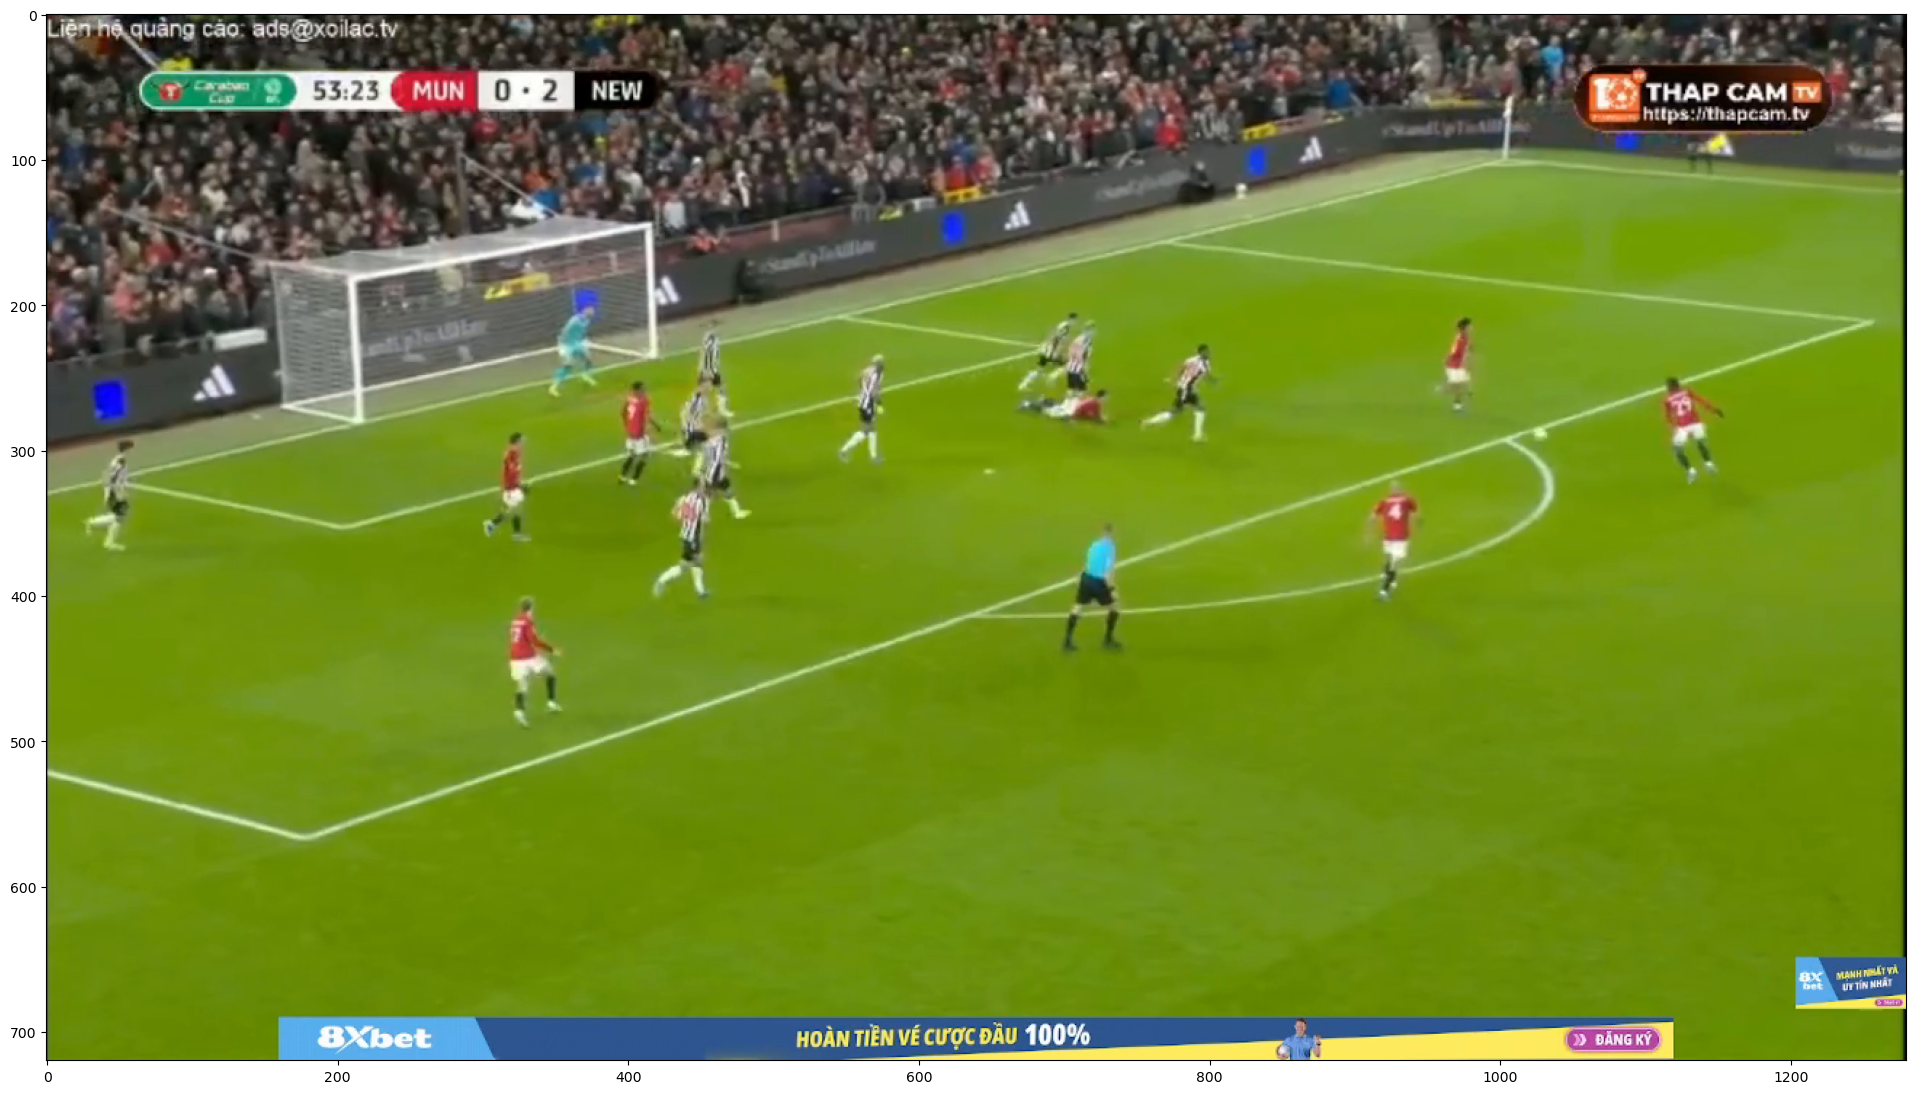

In [28]:
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
print(images_path)
image_path = os.path.join(images_path, os.listdir(images_path)[21])

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])


0: 576x1024 17 persons, 1 ball, 155.0ms
Speed: 7.0ms preprocess, 155.0ms inference, 1.0ms postprocess per image at shape (1, 3, 576, 1024)


Center Coordinates: (335, 444)
Bottom Line Center: (335, 486)
Center Coordinates: (561, 272)
Bottom Line Center: (561, 310)
Center Coordinates: (1131, 285)
Bottom Line Center: (1131, 321)
Center Coordinates: (319, 325)
Bottom Line Center: (319, 363)
Center Coordinates: (781, 260)
Bottom Line Center: (781, 294)
Center Coordinates: (721, 395)
Bottom Line Center: (721, 440)
Center Coordinates: (464, 316)
Bottom Line Center: (464, 350)
Center Coordinates: (927, 363)
Bottom Line Center: (927, 403)
Center Coordinates: (406, 288)
Bottom Line Center: (406, 325)
Center Coordinates: (970, 241)
Bottom Line Center: (970, 275)
Center Coordinates: (436, 362)
Bottom Line Center: (436, 403)
Center Coordinates: (45, 332)
Bottom Line Center: (45, 369)
Center Coordinates: (363, 221)
Bottom Line Center: (363, 262)
Center Coordinates: (449, 286)
Bottom Line Center: (449, 322)
Center Coordinates: (708, 245)
Bottom Line Center: (708, 281)
Center Coordinates: (455, 252)
Bottom Line Center: (455, 286)
Center C

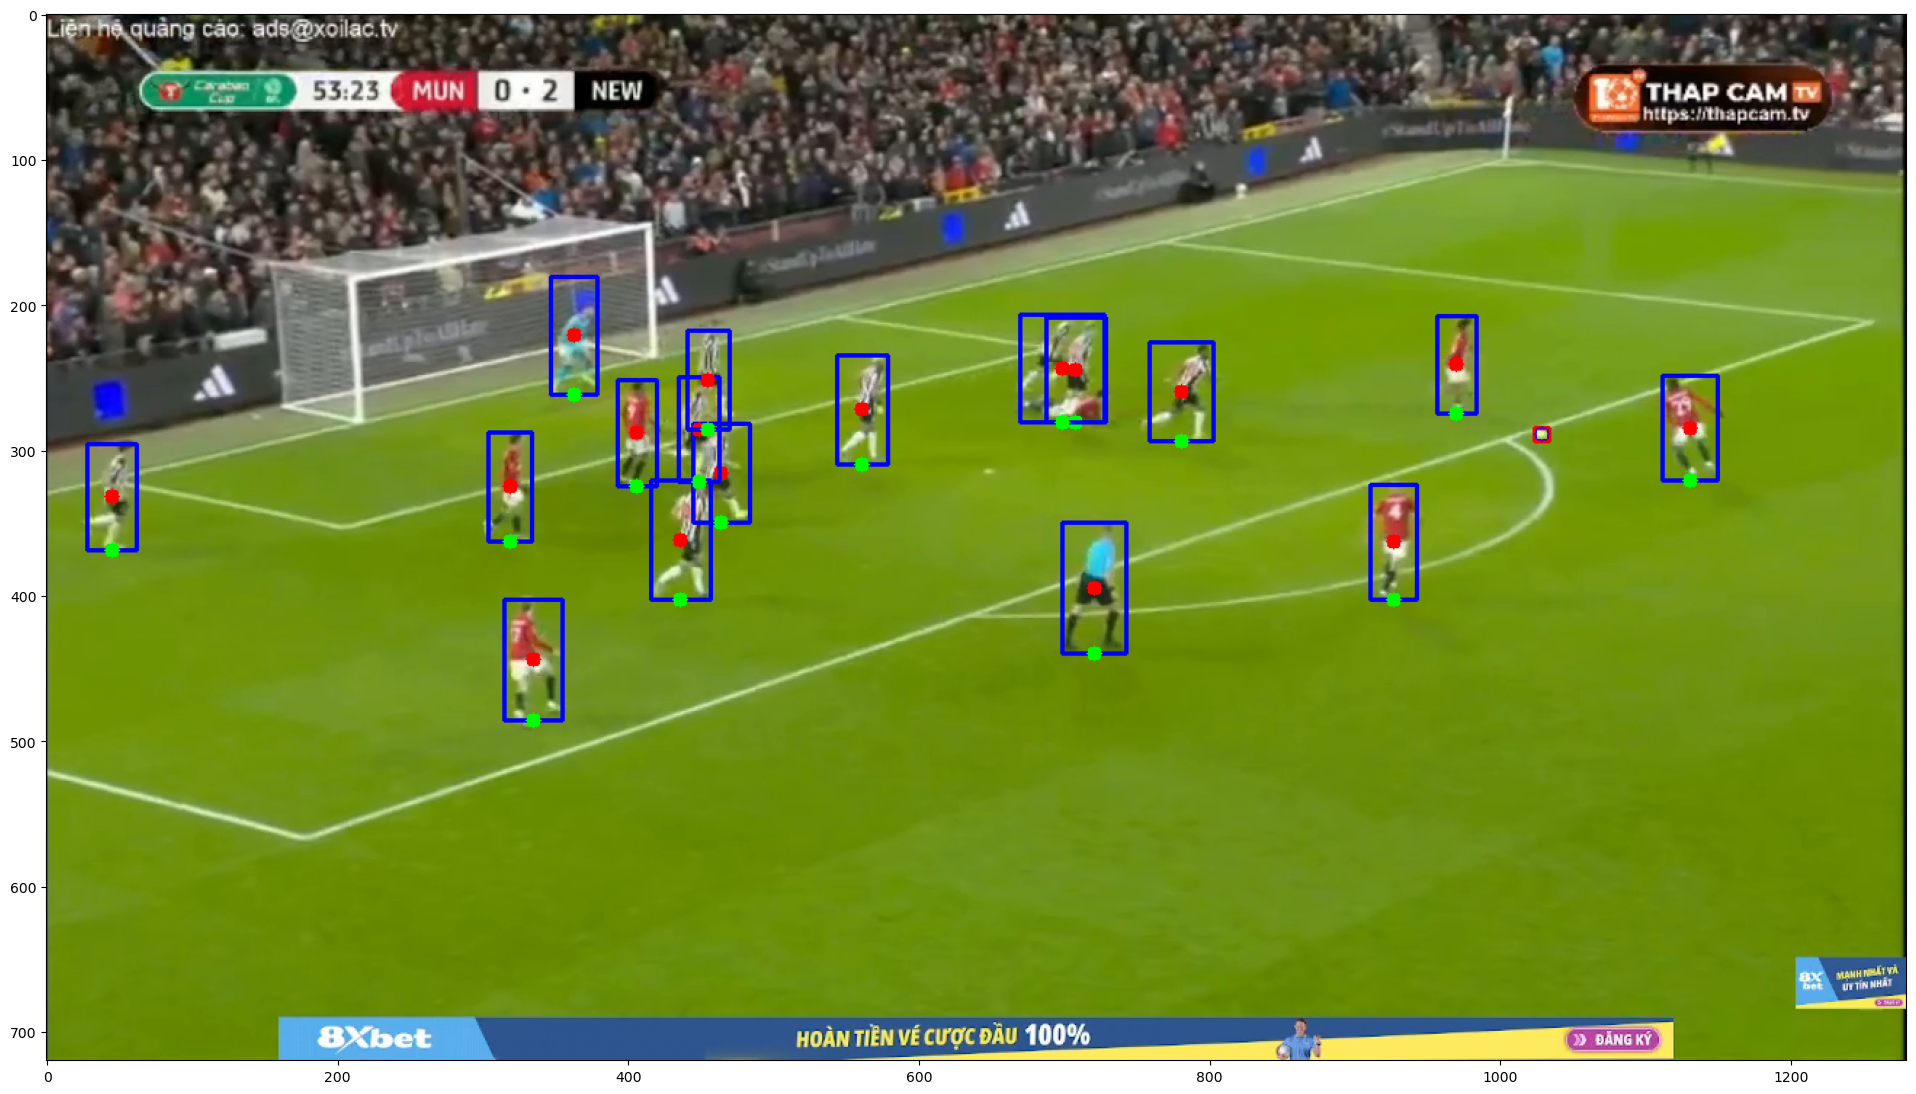

In [29]:
temp = rgb_image.copy()
center_coordinates = []
ball_center_coordinates = []
bottom_line_centers = []

results = model.predict(rgb_image)

for result in results:
    boxes = result.boxes
    classes = result.names
    for box in boxes:
        coord = box.xyxy.cpu().detach().int().tolist()[0]
        class_id = box.cls[0].item()
        if class_id != 1.0:
            (startX, startY, endX, endY) = coord
            cv2.rectangle(temp, (startX, startY), (endX, endY), (255, 0, 0), 2)

            centerX = (startX + endX) // 2
            centerY = (startY + endY) // 2
            center_coordinates.append((centerX, centerY))
            cv2.circle(temp, (centerX, centerY), 5, (0, 0, 255), -1)
            
            bottom_centerX = (startX + endX) // 2
            bottom_centerY = endY
            bottom_line_centers.append((bottom_centerX, bottom_centerY))
            cv2.circle(temp, (bottom_centerX, bottom_centerY), 5, (0, 255, 0), -1)

        else:
            (ball_startX, ball_startY, ball_endX, ball_endY) = coord
            cv2.rectangle(temp, (ball_startX, ball_startY), (ball_endX, ball_endY), (0, 0, 255), 2)
            
            ball_centerX = (ball_startX + ball_endX) // 2
            centerY = (ball_startY + ball_endY) // 2
            ball_center_coordinates.append((ball_centerX, ball_centerY))
            cv2.circle(temp, (ball_centerX, ball_centerY), 5, (255, 0, 0), 1)
        
for center_coord, bottom_center in zip(center_coordinates, bottom_line_centers):
    print("Center Coordinates:", center_coord)
    print("Bottom Line Center:", bottom_center)
    
for ball_coord in ball_center_coordinates:
    print("Ball Center Coordinates:", ball_coord)
        
plt.figure()
plt.imshow(temp[:,:,::-1])

Center Coordinates: (335, 444)
Bottom Line Center: (335, 486)
Center Coordinates: (561, 272)
Bottom Line Center: (561, 310)
Center Coordinates: (1131, 285)
Bottom Line Center: (1131, 321)
Center Coordinates: (319, 325)
Bottom Line Center: (319, 363)
Center Coordinates: (781, 260)
Bottom Line Center: (781, 294)
Center Coordinates: (721, 395)
Bottom Line Center: (721, 440)
Center Coordinates: (464, 316)
Bottom Line Center: (464, 350)
Center Coordinates: (927, 363)
Bottom Line Center: (927, 403)
Center Coordinates: (406, 288)
Bottom Line Center: (406, 325)
Center Coordinates: (970, 241)
Bottom Line Center: (970, 275)
Center Coordinates: (436, 362)
Bottom Line Center: (436, 403)
Center Coordinates: (45, 332)
Bottom Line Center: (45, 369)
Center Coordinates: (363, 221)
Bottom Line Center: (363, 262)
Center Coordinates: (449, 286)
Bottom Line Center: (449, 322)
Center Coordinates: (455, 252)
Bottom Line Center: (455, 286)
Ball Center Coordinates: (1029, 289)


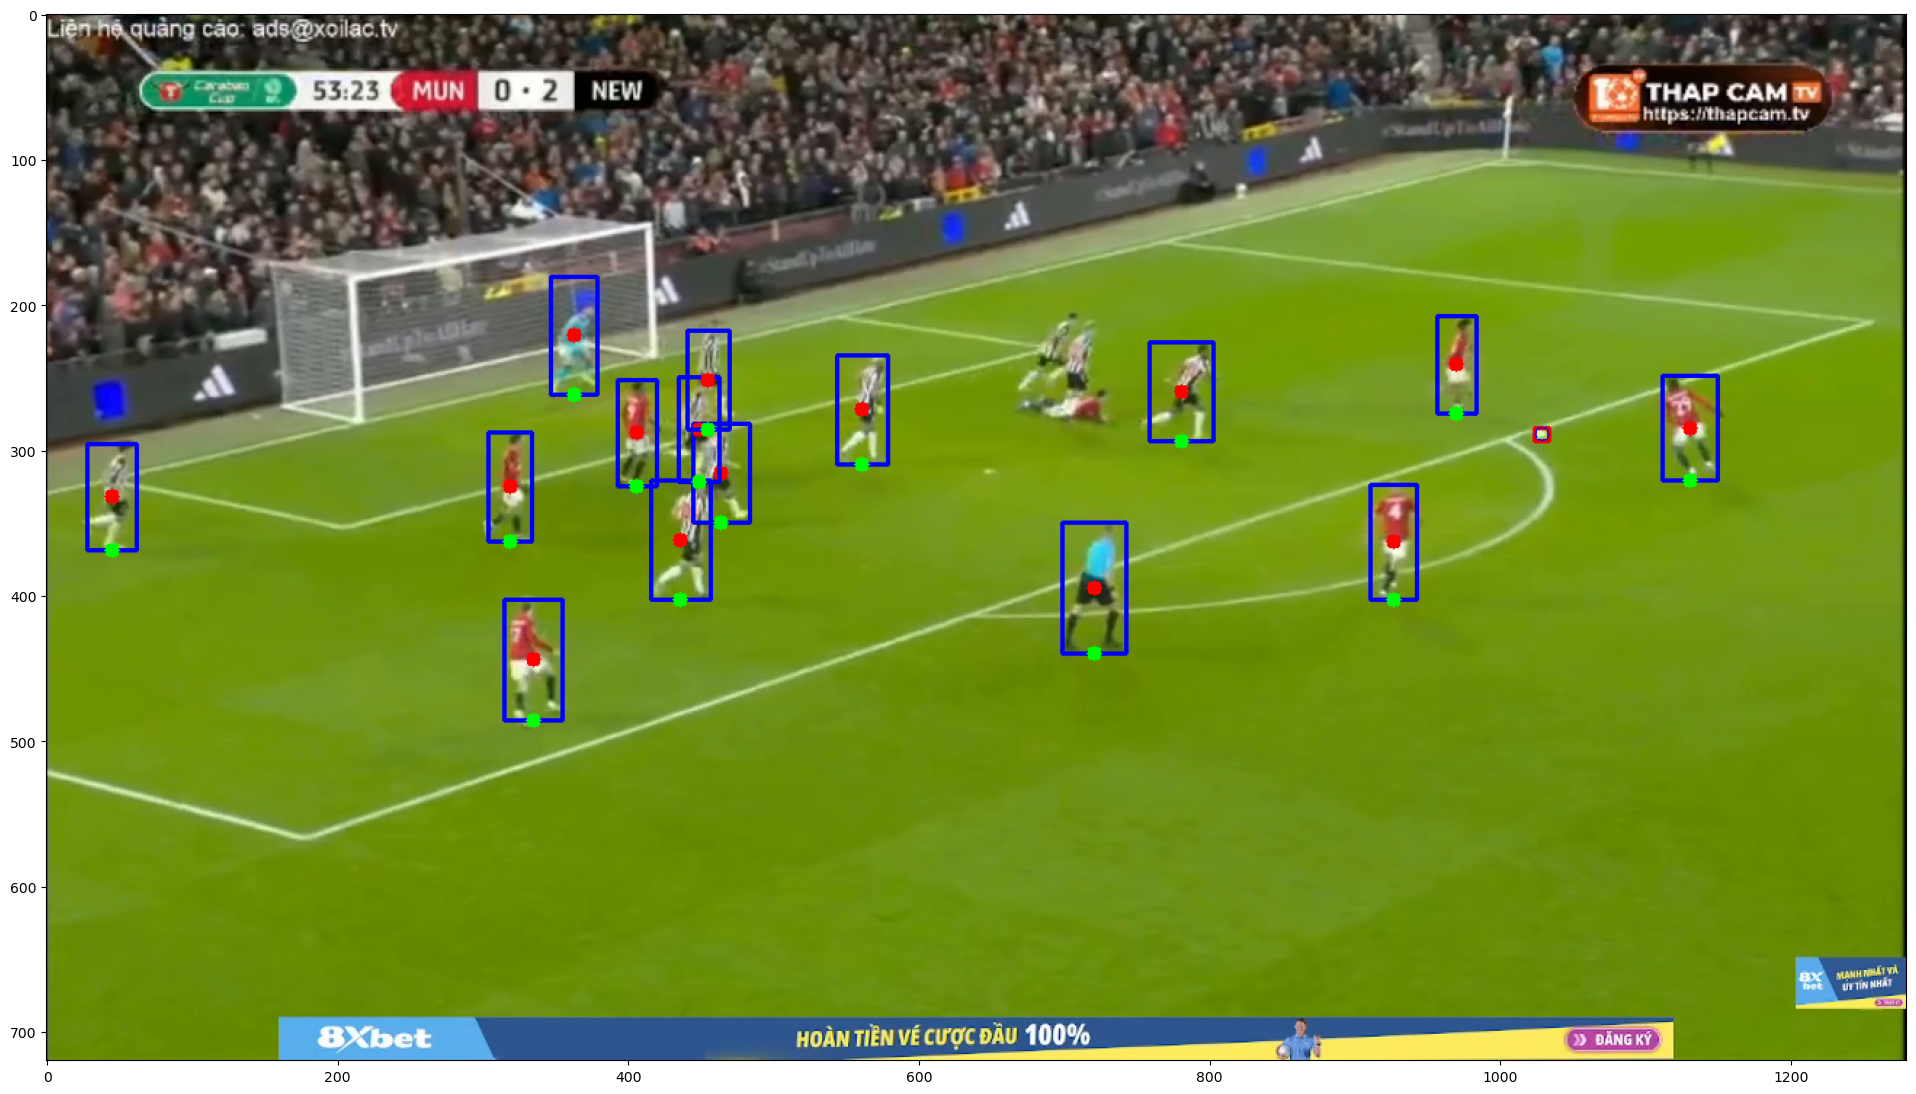

In [30]:
distance_threshold = 20
boxes_to_remove = []
for i in range(len(center_coordinates)):
    for j in range(i + 1, len(center_coordinates)):
        distance = np.linalg.norm(np.array(center_coordinates[i]) - np.array(center_coordinates[j]))
        if distance < distance_threshold:
            boxes_to_remove.extend([i, j])

new_boxes = [box for i, box in enumerate(results[0].boxes) if i not in boxes_to_remove]
center_coordinates = []
bottom_line_centers = []
ball_center_coordinates = []

temp = rgb_image.copy()
for box in new_boxes:
    coord = box.xyxy.cpu().detach().int().tolist()[0]
    class_id = box.cls[0].item()
    if class_id != 1.0:
        (startX, startY, endX, endY) = coord
        cv2.rectangle(temp, (startX, startY), (endX, endY), (255, 0, 0), 2)

        centerX = (startX + endX) // 2
        centerY = (startY + endY) // 2
        center_coordinates.append((centerX, centerY))
        cv2.circle(temp, (centerX, centerY), 5, (0, 0, 255), -1)

        bottom_centerX = (startX + endX) // 2
        bottom_centerY = endY
        bottom_line_centers.append((bottom_centerX, bottom_centerY))
        cv2.circle(temp, (bottom_centerX, bottom_centerY), 5, (0, 255, 0), -1)

    else:
        (ball_startX, ball_startY, ball_endX, ball_endY) = coord
        cv2.rectangle(temp, (ball_startX, ball_startY), (ball_endX, ball_endY), (0, 0, 255), 2)

        ball_centerX = (ball_startX + ball_endX) // 2
        centerY = (ball_startY + ball_endY) // 2
        ball_center_coordinates.append((ball_centerX, ball_centerY))
        cv2.circle(temp, (ball_centerX, ball_centerY), 5, (255, 0, 0), 1)

for center_coord, bottom_center in zip(center_coordinates, bottom_line_centers):
    print("Center Coordinates:", center_coord)
    print("Bottom Line Center:", bottom_center)
    
for ball_coord in ball_center_coordinates:
    print("Ball Center Coordinates:", ball_coord)

plt.figure()
plt.imshow(temp[:, :, ::-1])
plt.show()